# Notebook de Optimización: Método de Bisección

Este cuaderno implementa el método de Bisección, también conocido como de corte binario, partición de intervalos o de Bolzano, para encontrar la raíz de una función dentro de un intervalo especificado. Visualiza la función, el punto de raíz encontrado y la convergencia del error a lo largo de las iteraciones.

## ¿Qué es el Método de Bisección?

El método de bisección es un tipo de búsqueda incremental en el que el intervalo se divide siempre a la mitad.

Si la función cambia de signo sobre un intervalo, se evalúa el valor de la función en el punto medio. La posición de la raíz se determina situándola en el punto medio del subintervalo dentro del cual ocurre un cambio de signo.

## Algoritmo

**Paso 1:** Elija valores iniciales inferior, x_l, y superior, x_u, que encierren la raíz, de forma tal que la función cambie de signo en el intervalo. Esto se verifica comprobando que f(x_l) · f(x_u) < 0.

**Paso 2:** Una aproximación de la raíz x_r se determina mediante: x_r = (x_l + x_u) / 2

**Paso 3:** Realice las siguientes evaluaciones para determinar en qué subintervalo está la raíz:
- a) Si f(x_l) · f(x_r) < 0, entonces la raíz se encuentra dentro del subintervalo superior o derecho. Por lo tanto, haga x_u = x_r y vuelva al paso 2.
- b) Si f(x_l) · f(x_r) > 0, entonces la raíz se encuentra dentro del subintervalo inferior o izquierdo. Por lo tanto, haga x_l = x_r y vuelva al paso 2.
- c) Si f(x_l) · f(x_r) = 0, la raíz es igual a x_r; termina el cálculo.

## Número de Iteraciones

En cada iteración el intervalo se reduce a la mitad, por tanto:

(x_u - x_l) / 2^n < Error_dado

Despejando n: n > log(x_u - x_l) - log(Error) / log(2)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
def funcion_ejemplo(x):
    """
    Función de ejemplo para encontrar la raíz.
    f(x) = 3x^2 - 120x + 100
    Tiene raíces en el intervalo [35, 45]
    """
    return 3*x**2 - 120*x + 100

In [9]:
def biseccion_buscar_raiz(func, xl, xu, tol=1e-6, max_iter=1000):
    """
    Implementa el método de bisección para encontrar la raíz de una función.

    Args:
        func (callable): Función para la cual buscar la raíz.
        xl (float): Límite inferior del intervalo (x_l).
        xu (float): Límite superior del intervalo (x_u).
        tol (float): Tolerancia para la aproximación.
        max_iter (int): Número máximo de iteraciones.

    Returns:
        tuple: (x_raiz, f_raiz, historial_error, iteraciones)
    """
    if xl >= xu:
        raise ValueError("El intervalo debe cumplir xl < xu.")

    f_xl = func(xl)
    f_xu = func(xu)

    if f_xl * f_xu > 0:
        raise ValueError(f"No hay cambio de signo en el intervalo [{xl}, {xu}]. f(xl)={f_xl:.4f}, f(xu)={f_xu:.4f}")

 
    iteraciones = 0

    for i in range(1, max_iter + 1):
        xr = (xl + xu) / 2
        f_xr = func(xr)

        historial_error.append((i, xu - xl))
        iteraciones = i

        # Criterio de parada
        if abs(f_xr) < tol or abs(xu - xl) < tol:
            break

        # Determinar en qué subintervalo está la raíz
        if f_xl * f_xr < 0:
            # La raíz está en [xl, xr]
            xu = xr
            f_xu = f_xr
        elif f_xl * f_xr > 0:
            # La raíz está en [xr, xu]
            xl = xr
            f_xl = f_xr
        else:
            # f_xr = 0, hemos encontrado la raíz
            break

    x_raiz = (xl + xu) / 2
    f_raiz = func(x_raiz)
    
    return x_raiz, f_raiz, historial_error, iteraciones

In [10]:
# Parámetros del método
xl = 35                # Límite inferior (x_l)
xu = 45                # Límite superior (x_u)
tol = 1e-6             # Tolerancia

# Ejecutar el método de bisección
x_raiz, f_raiz, historial_error, iteraciones = biseccion_buscar_raiz(funcion_ejemplo, xl, xu, tol)

# Mostrar resultados
print("="*60)
print("MéTODO DE BISECCIÓN")
print("="*60)
print(f"Raíz encontrada: x = {x_raiz:.10f}")
print(f"Valor de la función: f(x) = {f_raiz:.2e}")
print(f"Número de iteraciones: {iteraciones}")
print(f"Intervalo final: [{xl:.10f}, {xu:.10f}]")
print(f"Amplitud final del intervalo: {historial_error[-1][1]:.2e}")
print("="*60)

# Crear tabla de convergencia
datos_convergencia = []
for i, amplitud in historial_error:
    datos_convergencia.append({
        'Iteración': i,
        'Amplitud': amplitud,
        'Log10(Amplitud)': np.log10(amplitud) if amplitud > 0 else np.nan
    })

df_convergencia = pd.DataFrame(datos_convergencia)
print("\nTabla de Convergencia:")
print(df_convergencia.to_string(index=False))

MéTODO DE BISECCIÓN
Raíz encontrada: x = 39.1485419869
Valor de la función: f(x) = -1.93e-05
Número de iteraciones: 25
Intervalo final: [35.0000000000, 45.0000000000]
Amplitud final del intervalo: 5.96e-07

Tabla de Convergencia:
 Iteración     Amplitud  Log10(Amplitud)
         0 0.000000e+00              NaN
         1 1.000000e+01          1.00000
         2 5.000000e+00          0.69897
         3 2.500000e+00          0.39794
         4 1.250000e+00          0.09691
         5 6.250000e-01         -0.20412
         6 3.125000e-01         -0.50515
         7 1.562500e-01         -0.80618
         8 7.812500e-02         -1.10721
         9 3.906250e-02         -1.40824
        10 1.953125e-02         -1.70927
        11 9.765625e-03         -2.01030
        12 4.882812e-03         -2.31133
        13 2.441406e-03         -2.61236
        14 1.220703e-03         -2.91339
        15 6.103516e-04         -3.21442
        16 3.051758e-04         -3.51545
        17 1.525879e-04         

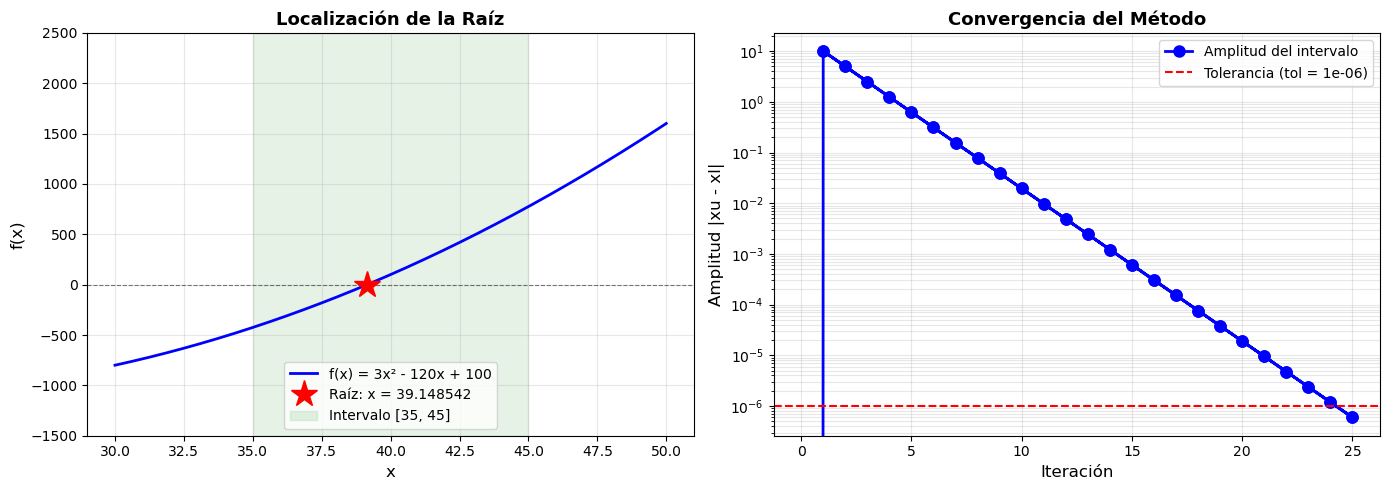

In [13]:
# Graficar la función y la raíz
x_vals = np.linspace(30, 50, 1000)
y_vals = funcion_ejemplo(x_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Función y raíz
ax1.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = 3x² - 120x + 100')
ax1.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.plot(x_raiz, f_raiz, 'r*', markersize=20, label=f'Raíz: x = {x_raiz:.6f}')
ax1.fill_between([35, 45], -1500, 2500, alpha=0.1, color='green', label='Intervalo [35, 45]')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.set_title('Localización de la Raíz', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_ylim(-1500, 2500)

# Gráfica 2: Convergencia del intervalo
iteraciones_list = [item[0] for item in historial_error]
amplitudes = [item[1] for item in historial_error]

ax2.semilogy(iteraciones_list, amplitudes, 'bo-', linewidth=2, markersize=8, label='Amplitud del intervalo')
ax2.axhline(y=tol, color='r', linestyle='--', linewidth=1.5, label=f'Tolerancia (tol = {tol})')
ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel('Amplitud |xu - xl|', fontsize=12)
ax2.set_title('Convergencia del Método', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()


ANÁLISIS DE CONVERGENCIA

Teoría de Convergencia:
Para el método de bisección, la amplitud del intervalo en la iteración n es:
    Amplitud_n = Amplitud_0 / 2^n

Amplitud inicial: 10.000000
Amplitud final: 5.96e-07

Convergencia lineal (factor de reducción = 0.5):
Iteración | Amplitud Teórica | Amplitud Real | Error
------------------------------------------------------------
   0     |       1.00e+01 |       0.00e+00 | 100.00%
   1     |       5.00e+00 |       1.00e+01 | 100.00%
   2     |       2.50e+00 |       5.00e+00 | 100.00%
   3     |       1.25e+00 |       2.50e+00 | 100.00%
   4     |       6.25e-01 |       1.25e+00 | 100.00%
   5     |       3.12e-01 |       6.25e-01 | 100.00%
   6     |       1.56e-01 |       3.12e-01 | 100.00%
   7     |       7.81e-02 |       1.56e-01 | 100.00%
   8     |       3.91e-02 |       7.81e-02 | 100.00%
   9     |       1.95e-02 |       3.91e-02 | 100.00%


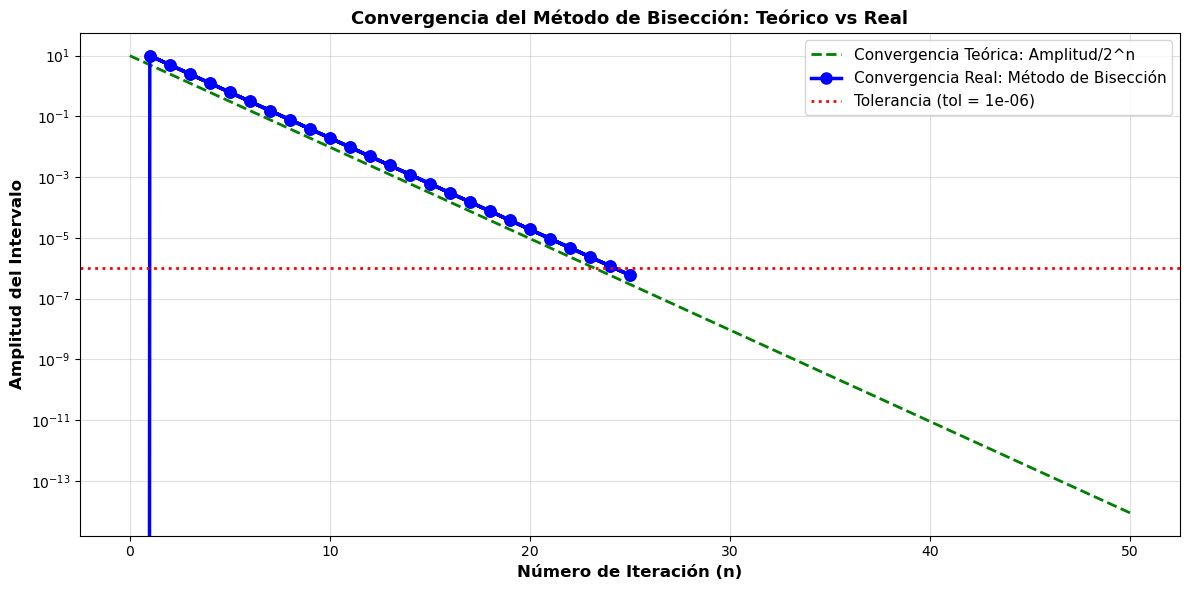

In [14]:
# Análisis de convergencia
print("\n" + "="*60)
print("ANÁLISIS DE CONVERGENCIA")
print("="*60)

# Teorema: El error en la iteración n es aproximadamente (xu - xl) / 2^n
print("\nTeoría de Convergencia:")
print("Para el método de bisección, la amplitud del intervalo en la iteración n es:")
print("    Amplitud_n = Amplitud_0 / 2^n")

# Calcular orden de convergencia lineal
amplitud_inicial = historial_error[1][1]
print(f"\nAmplitud inicial: {amplitud_inicial:.6f}")
print(f"Amplitud final: {historial_error[-1][1]:.2e}")

print("\nConvergencia lineal (factor de reducción = 0.5):")
print("Iteración | Amplitud Teórica | Amplitud Real | Error")
print("-" * 60)

for i in range(min(10, len(historial_error))):
    amplitud_teorica = amplitud_inicial / (2 ** i)
    amplitud_real = historial_error[i][1]
    error_rel = abs(amplitud_teorica - amplitud_real) / amplitud_teorica * 100
    print(f"{i:4d}     | {amplitud_teorica:14.2e} | {amplitud_real:14.2e} | {error_rel:6.2f}%")

# Visualización de convergencia teórica vs real
fig, ax = plt.subplots(figsize=(12, 6))

# Convergencia teórica
iters_teorica = np.arange(len(historial_error))
amplitudes_teorica = [amplitud_inicial / (2 ** i) for i in iters_teorica]

ax.semilogy(iters_teorica, amplitudes_teorica, 'g--', linewidth=2,
            markersize=6, label='Convergencia Teórica: Amplitud/2^n')
ax.semilogy(iteraciones_list, amplitudes, 'bo-', linewidth=2.5,
            markersize=8, label='Convergencia Real: Método de Bisección')
ax.axhline(y=tol, color='r', linestyle=':', linewidth=2, label=f'Tolerancia (tol = {tol})')
ax.set_xlabel('Número de Iteración (n)', fontsize=12, fontweight='bold')
ax.set_ylabel('Amplitud del Intervalo', fontsize=12, fontweight='bold')
ax.set_title('Convergencia del Método de Bisección: Teórico vs Real', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.4, which='both')
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

print("\n" + "="*60)